# Step 3 — Tensor-network Backend with Contraction Path Reuse

**CUDA-Q QAOA GPU-Optimization Learning Path · notebook 3 of 4 (Read-only)**

Notebook 02 solved the 9-zone coloring with the XY circuit — but each energy evaluation take quite long, so five optimizer steps were all we could afford. This notebook keeps the
*exact same problem and circuit* and attacks the cost itself.

**Where does the time go?** Before a tensor-network simulator combines ("contracts") its web of
small tensors, it must **plan the order** in which to combine them — like choosing the order of
a long chain of matrix multiplications, where a good order can be exponentially cheaper than a
bad one. By default, the simulator re-plans from scratch for **across repeated `observe` calls for energy evaluation**. Two environment variables change that:

- `CUDAQ_TENSORNET_OBSERVE_CONTRACT_PATH_REUSE` — remember the contraction path and **reuse it** on every
  later evaluation. Our circuit's *shape* never changes between evaluations (only the angle
  values inside the gates do).
- `CUDAQ_TENSORNET_NUM_HYPER_SAMPLES` — how many candidate path planner explores (default
  8). More search costs planning time once, but can find a more compute-efficient path for every contraction.

**Below is an example sweep** (same 36-qubit XY workload at a fixed set of angles; first evaluation, then
three repeats):

| setting | evaluation |
|---|---|
| reuse OFF, 8 hyper samples (the default — notebook 02 ran this) | ~84 s |
| reuse OFF, 32 hyper samples | 83 s |
| reuse ON, 4 hyper samples | 38 s |
| reuse ON, 8 hyper samples | 13 s |
| reuse ON, 16 hyper samples | 11 s |
| **reuse ON, 32 hyper samples — used below** | **10 s** |

As shown above, reusing the path saves significant time, while additional path-finding may identify an even better path.
And as always: the variables are read when CUDA-Q is imported, so they sit at the very top of the
first cell (restart the kernel if you change them).

In [1]:
# Cell 1 — chosen tensor-network settings FIRST. Then, construct the same primitive from the QUBO in a CUDA-Q-compatible format.
import os
os.environ["CUDAQ_TENSORNET_OBSERVE_CONTRACT_PATH_REUSE"] = "TRUE"   # remember contraction plans
os.environ["CUDAQ_TENSORNET_NUM_HYPER_SAMPLES"] = "32"               # search harder for good plans

import sys, time
import matplotlib.pyplot as plt
import helpers as hp
import cudaq            # <- the settings above are picked up here

cudaq.set_random_seed(1234)
cudaq.set_target("tensornet", option="fp32")
print(f"CUDA-Q {cudaq.__version__.split()[2]}   Python {sys.version.split()[0]}")

taiwan = hp.load_map()
NODES = hp.ZONE_ORDER                # the 9 zones, as in notebook 02
EDGES = taiwan["zone_edges"]         # 14 zone borders
K = 4                                # colors
A, B = 8.0, 1.0                      # same penalties as notebook 02
N = len(NODES) * K                   # 36 qubits

coeffs, qubo_offset = hp.build_qubo(NODES, EDGES, K, A, B)
H, terms, offset = hp.qubo_to_spin(coeffs, qubo_offset)
zq, zc, zz1, zz2, zzc = hp.terms_to_lists(terms)

CUDA-Q amd64-cu13-0.15.0   Python 3.12.3


## 1 · The same XY circuit

Similar setting as usual — W-state start (exactly one color per zone by construction),
the usual cost layer, and the XY ring mixer that swaps each zone's single "1" around. Only one-
and two-qubit gates.

In [2]:
# Cell 2 — the XY circuit (identical to notebook 02).
W_ANGLES = [2.0943951023931953, 1.9106332362490186, 1.5707963267948966]

@cudaq.kernel
def xy_kernel(n: int, zq: list[int], zc: list[float], zz1: list[int],
              zz2: list[int], zzc: list[float], wa: list[float],
              ra: list[int], rb: list[int], gammas: list[float], betas: list[float]):
    q = cudaq.qvector(n)
    for v in range(n // 4):                           # W-state start on each zone
        base = 4 * v
        x(q[base])
        for k in range(3):
            ry.ctrl(wa[k], q[base + k], q[base + k + 1])
            x.ctrl(q[base + k + 1], q[base + k])
    for layer in range(len(gammas)):
        for i in range(len(zq)):                      # cost layer
            rz(2.0 * gammas[layer] * zc[i], q[zq[i]])
        for i in range(len(zz1)):
            x.ctrl(q[zz1[i]], q[zz2[i]])
            rz(2.0 * gammas[layer] * zzc[i], q[zz2[i]])
            x.ctrl(q[zz1[i]], q[zz2[i]])
        for i in range(len(ra)):                      # XY mixer: swap the "1" around the ring
            a = ra[i]
            b = rb[i]
            h(q[a])
            h(q[b])
            x.ctrl(q[a], q[b])
            rz(2.0 * betas[layer], q[b])
            x.ctrl(q[a], q[b])
            h(q[a])
            h(q[b])
            rx(1.5707963267948966, q[a])
            rx(1.5707963267948966, q[b])
            x.ctrl(q[a], q[b])
            rz(2.0 * betas[layer], q[b])
            x.ctrl(q[a], q[b])
            rx(-1.5707963267948966, q[a])
            rx(-1.5707963267948966, q[b])

ring_a, ring_b = [], []
for v in range(len(NODES)):                           # ring pairs (0-1, 1-2, 2-3, 3-0) per zone
    for a, b in [(0, 1), (1, 2), (2, 3), (3, 0)]:
        ring_a.append(4 * v + a)
        ring_b.append(4 * v + b)

def energy(params):
    return cudaq.observe(xy_kernel, H, N, zq, zc, zz1, zz2, zzc, W_ANGLES,
                         ring_a, ring_b, [params[0]], [params[1]]).expectation() + offset

## 2 · A real optimization run on cheaper evaluations

With reuse ON, the found path is shared across energy evaluations because their contraction paths are cached.
Same five-evaluation Nelder–Mead run as notebook 02, but now on the path-reused evaluations
measured above — so the evaluation time is substantially reduced. The optimization starts
fresh from `[0.1, 0.1]` (no angles are carried over from earlier notebooks). Again, verify for
yourself whether the energy can be lowered even further by spending a larger budget.

In [3]:
# Cell 3 — Nelder-Mead again, now on the cheaper (path-reused) evaluations.
num_iterations = 5
START = [0.1, 0.1]

optimizer = cudaq.optimizers.NelderMead()
optimizer.max_iterations = num_iterations
optimizer.initial_parameters = START
start = time.perf_counter()
best_energy, theta_star = optimizer.optimize(dimensions=2, function=energy)
t_opt = time.perf_counter() - start
print(f"best energy {best_energy:.4f} at gamma = {theta_star[0]:.4f}, "
      f"beta = {theta_star[1]:.4f}   ({t_opt:.0f} s for {num_iterations} evaluations)")

best energy 3.5030 at gamma = -1.4708, beta = 3.1416   (191 s for 5 evaluations)


## 3 · Sample, decode, check

Same drill as notebook 02: sample only after optimizing, decode every bitstring, and apply the
series' one check — the best sampled bitstring must be a valid zone coloring.

In [4]:
# Cell 4 — 2,000 shots at the new best angles.
SHOTS = 2000
start = time.perf_counter()
result = cudaq.sample(xy_kernel, N, zq, zc, zz1, zz2, zzc, W_ANGLES,
                      ring_a, ring_b, [theta_star[0]], [theta_star[1]], shots_count=SHOTS)
t_sample = time.perf_counter() - start
counts = {}
for bitstring, times_seen in result.items():
    counts[bitstring] = times_seen
print(f"sampled {SHOTS:,} shots in {t_sample:.0f} s")

summary = hp.summarize_samples(counts, NODES, K, EDGES, coeffs, qubo_offset)

# THE check of this notebook: the sampled answer really is a valid zone coloring.
assert summary["best"] is not None and hp.is_valid(summary["best"], NODES, K, EDGES)
print("check passed: the best sampled bitstring is a valid zone coloring (energy 0)")

sampled 2,000 shots in 79 s
valid colorings among raw samples: 16 / 2,000 shots = 0.8000%  (16 distinct bitstrings)
best valid coloring: '100000100100000100100100001010000100' (sampled 1 times, energy 0.0)
   Taipei=0, Keelung=2, Taoyuan-Hsinchu-Miaoli=1, Yilan=3, Taichung-Changhua-Nantou=2, Yunlin-Chiayi=1, Tainan=2, South=0, East=1
check passed: the best sampled bitstring is a valid zone coloring (energy 0)


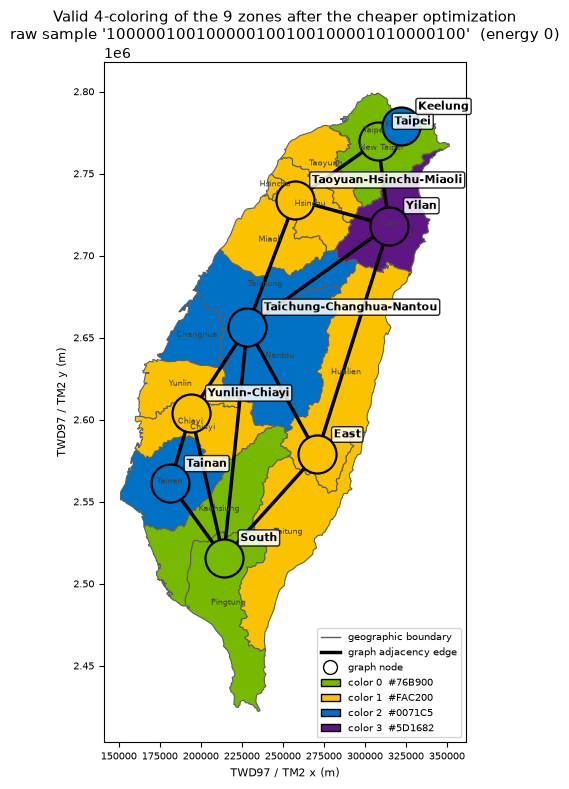

In [5]:
# Cell 5 — visualize on the map for the coloring.
best_coloring = summary["assignment"]
unit_colors = {}
for name, county in taiwan["counties"].items():
    unit_colors[name] = hp.PALETTE[best_coloring[county["zone"]]]
node_colors = {}
for zone in hp.ZONE_ORDER:
    node_colors[zone] = hp.PALETTE[best_coloring[zone]]

fig, ax = hp.plot_map(taiwan, unit_colors=unit_colors,
                      node_pos=hp.group_positions(taiwan, "zone"),
                      edges=EDGES, node_colors=node_colors,
                      unit_labels=True, color_legend=True,
                      title="Valid 4-coloring of the 9 zones after the cheaper optimization\n"
                            f"raw sample '{summary['best']}'  (energy 0)")
plt.show()

## 5 · What you should take away

**Planning is a real cost.** A tensor-network evaluation = path-finding + contract. When the circuit shape is fixed — as in every QAOA loop — replanning each time is waste, and `CUDAQ_TENSORNET_OBSERVE_CONTRACT_PATH_REUSE` recovers it. In addition, we can slightly increase `CUDAQ_TENSORNET_NUM_HYPER_SAMPLES` to search for an even better path and further reduce contraction time.

Now, we can move from exact tensor-network simulation to its approximate counterpart, matrix product states (MPS), to achieve further speedups with some trade-off in accuracy.